In [ ]:
!pip install torch-geometric
!pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.3.0+cu121.html

Looking in links: https://data.pyg.org/whl/torch-2.3.0+cu121.html


In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

PyTorch version: 2.11.0+cu128
CUDA available: True
Using device: cuda


In [ ]:
# Download and load the Cora dataset
dataset = Planetoid(root='/tmp/Cora', name='Cora', transform=NormalizeFeatures())
data = dataset[0].to(device)

# Explore the dataset
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Dataset name        : {dataset.name}")
print(f"Number of graphs    : {len(dataset)}")
print(f"Number of features  : {dataset.num_features}")
print(f"Number of classes   : {dataset.num_classes}")
print()
print("GRAPH STRUCTURE")
print("=" * 50)
print(f"Number of nodes     : {data.num_nodes}")
print(f"Number of edges     : {data.num_edges}")
print(f"Node feature shape  : {data.x.shape}")
print(f"Has self-loops      : {data.has_self_loops()}")
print(f"Is undirected       : {data.is_undirected()}")
print()
print("TRAIN / VAL / TEST SPLIT")
print("=" * 50)
print(f"Training nodes      : {data.train_mask.sum().item()}")
print(f"Validation nodes    : {data.val_mask.sum().item()}")
print(f"Test nodes          : {data.test_mask.sum().item()}")

Processing...
Done!


DATASET OVERVIEW
Dataset name        : Cora
Number of graphs    : 1
Number of features  : 1433
Number of classes   : 7

GRAPH STRUCTURE
Number of nodes     : 2708
Number of edges     : 10556
Node feature shape  : torch.Size([2708, 1433])
Has self-loops      : False
Is undirected       : True

TRAIN / VAL / TEST SPLIT
Training nodes      : 140
Validation nodes    : 500
Test nodes          : 1000


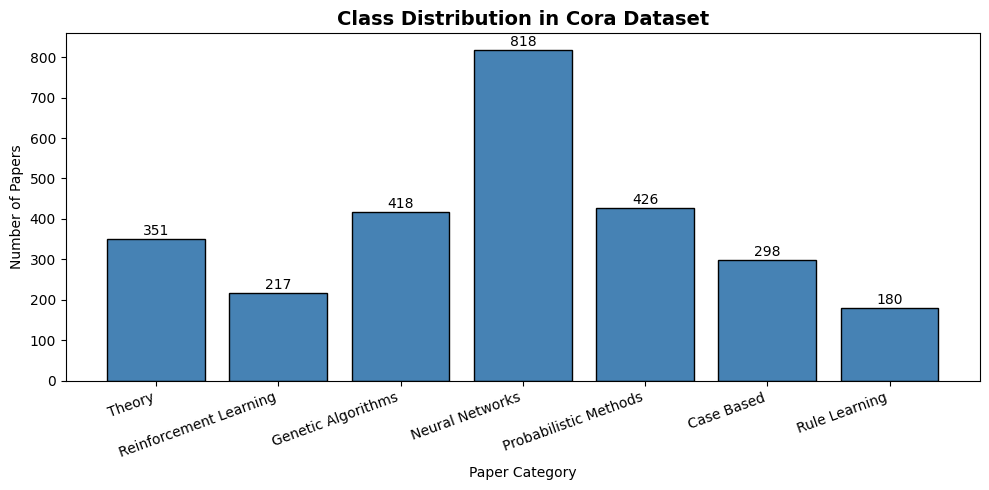

Total papers: 2708


In [ ]:
# Map class index to paper topic name
class_names = [
    'Theory',
    'Reinforcement Learning',
    'Genetic Algorithms',
    'Neural Networks',
    'Probabilistic Methods',
    'Case Based',
    'Rule Learning'
]

# Get labels
labels = data.y.cpu().numpy()
unique, counts = np.unique(labels, return_counts=True)

# Plot
plt.figure(figsize=(10, 5))
bars = plt.bar(class_names, counts, color='steelblue', edgecolor='black')
plt.title('Class Distribution in Cora Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Paper Category')
plt.ylabel('Number of Papers')
plt.xticks(rotation=20, ha='right')

# Add count labels on top of bars
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("Total papers:", sum(counts))

In [ ]:
class GCN(torch.nn.Module):
    """
    2-layer Graph Convolutional Network.

    Architecture:
        Input (1433 features)
            ↓
        GCNConv Layer 1 → 128 hidden units → ReLU → Dropout
            ↓
        GCNConv Layer 2 → 7 output units (one per class)
            ↓
        Log Softmax → Predicted class probabilities
    """

    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.5):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        # --- Layer 1 ---
        x = self.conv1(x, edge_index)   # Aggregate from neighbors
        x = F.relu(x)                   # Non-linearity
        x = F.dropout(x, p=self.dropout, training=self.training)  # Regularization

        # --- Layer 2 ---
        x = self.conv2(x, edge_index)   # Aggregate again (2-hop neighborhood)

        return F.log_softmax(x, dim=1)  # Class probabilities

    def get_embeddings(self, x, edge_index):
        """Returns intermediate embeddings (after layer 1) for visualization."""
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        return x


# Initialize model
model = GCN(
    input_dim=dataset.num_features,   # 1433
    hidden_dim=128,
    output_dim=dataset.num_classes,   # 7
    dropout=0.5
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# Print model summary
print("MODEL ARCHITECTURE")
print("=" * 50)
print(model)
print()

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

MODEL ARCHITECTURE
GCN(
  (conv1): GCNConv(1433, 128)
  (conv2): GCNConv(128, 7)
)

Total trainable parameters: 184,455


In [ ]:
def train(model, data, optimizer):
    """One training step."""
    model.train()
    optimizer.zero_grad()

    # Forward pass
    out = model(data.x, data.edge_index)

    # Loss only on training nodes (semi-supervised)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])

    # Backward pass
    loss.backward()
    optimizer.step()

    return loss.item()


def evaluate(model, data):
    """Evaluate on train, validation, and test sets."""
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out.argmax(dim=1)  # Pick class with highest probability

        results = {}
        for split in ['train', 'val', 'test']:
            mask = getattr(data, f'{split}_mask')
            correct = (pred[mask] == data.y[mask]).sum().item()
            total = mask.sum().item()
            results[split] = correct / total

    return results


print("Training and evaluation functions defined.")
print()
print("What happens during training:")
print("  1. Forward pass → compute embeddings for ALL nodes")
print("  2. Compute loss only on the 140 LABELED training nodes")
print("  3. Backpropagate through the graph layers")
print("  4. All 2708 nodes still benefit via message passing")
print("  This is called SEMI-SUPERVISED LEARNING")

Training and evaluation functions defined.

What happens during training:
  1. Forward pass → compute embeddings for ALL nodes
  2. Compute loss only on the 140 LABELED training nodes
  3. Backpropagate through the graph layers
  4. All 2708 nodes still benefit via message passing
  This is called SEMI-SUPERVISED LEARNING


In [ ]:
# Training loop
EPOCHS = 50

train_losses = []
train_accs = []
val_accs = []
test_accs = []

print("Training GCN on Cora...")
print("-" * 60)
print(f"{'Epoch':>6} | {'Loss':>8} | {'Train Acc':>10} | {'Val Acc':>8} | {'Test Acc':>9}")
print("-" * 60)

for epoch in range(1, EPOCHS + 1):
    loss = train(model, data, optimizer)
    metrics = evaluate(model, data)

    train_losses.append(loss)
    train_accs.append(metrics['train'])
    val_accs.append(metrics['val'])
    test_accs.append(metrics['test'])

    if epoch % 20 == 0 or epoch == 1:
        print(f"{epoch:>6} | {loss:>8.4f} | {metrics['train']:>9.2%} | "
              f"{metrics['val']:>7.2%} | {metrics['test']:>8.2%}")

print("-" * 60)
print(f"\nFinal Test Accuracy: {test_accs[-1]:.2%}")

Training GCN on Cora...
------------------------------------------------------------
 Epoch |     Loss |  Train Acc |  Val Acc |  Test Acc
------------------------------------------------------------
     1 |   1.9456 |    74.29% |  47.60% |   49.30%
    20 |   1.1278 |    97.14% |  78.00% |   79.20%
    40 |   0.4218 |    98.57% |  79.20% |   82.00%
------------------------------------------------------------

Final Test Accuracy: 81.50%


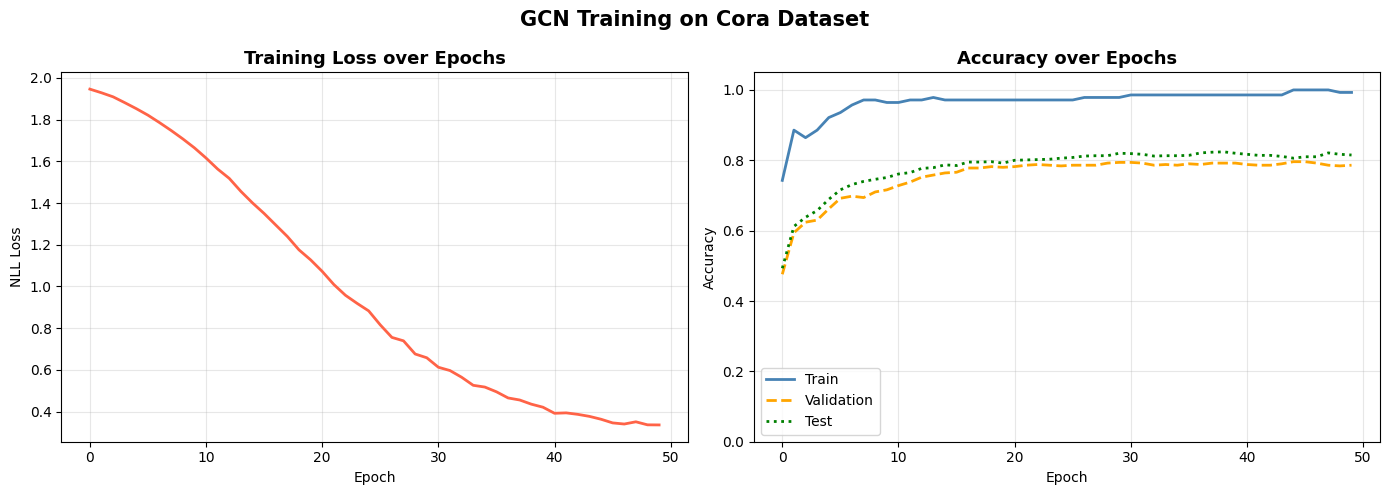

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Loss Curve ---
axes[0].plot(train_losses, color='tomato', linewidth=2)
axes[0].set_title('Training Loss over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('NLL Loss')
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Accuracy Curves ---
axes[1].plot(train_accs, label='Train', color='steelblue', linewidth=2)
axes[1].plot(val_accs,   label='Validation', color='orange', linewidth=2, linestyle='--')
axes[1].plot(test_accs,  label='Test', color='green', linewidth=2, linestyle=':')
axes[1].set_title('Accuracy over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1.05)

plt.suptitle('GCN Training on Cora Dataset', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

       MODEL COMPARISON — TEST ACCURACY
  MLP  (features only, no graph) : 59.50%
  GCN  (features + graph)        : 81.50%
  Improvement from graph         : +22.00%

The graph structure (citations) gave the GCN a
~22.0% boost in accuracy — for free!


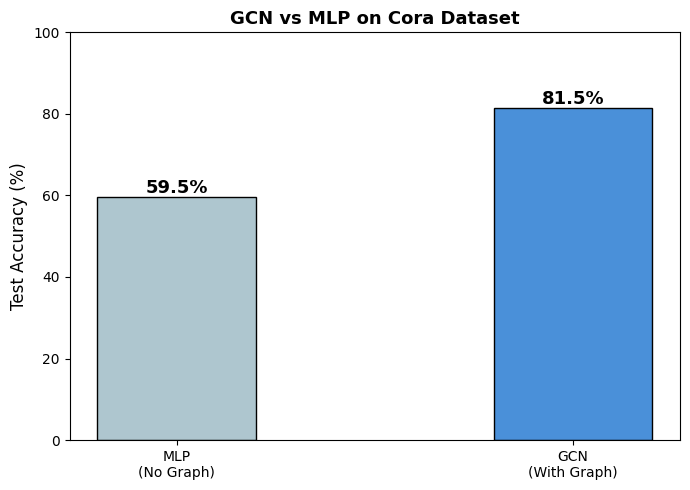

In [ ]:
class MLP(torch.nn.Module):
    """Simple 2-layer MLP — no graph structure, just node features."""
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.5):
        super(MLP, self).__init__()
        self.lin1 = torch.nn.Linear(input_dim, hidden_dim)
        self.lin2 = torch.nn.Linear(hidden_dim, output_dim)
        self.dropout = dropout

    def forward(self, x):
        x = F.relu(self.lin1(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin2(x)
        return F.log_softmax(x, dim=1)


# Train MLP
mlp_model = MLP(dataset.num_features, 128, dataset.num_classes).to(device)
mlp_optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.01, weight_decay=5e-4)
mlp_test_accs = []

for epoch in range(1, 201):
    mlp_model.train()
    mlp_optimizer.zero_grad()
    out = mlp_model(data.x)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    mlp_optimizer.step()

    mlp_model.eval()
    with torch.no_grad():
        pred = mlp_model(data.x).argmax(dim=1)
        correct = (pred[data.test_mask] == data.y[data.test_mask]).sum().item()
        mlp_test_accs.append(correct / data.test_mask.sum().item())

# Compare
gcn_final = test_accs[-1]
mlp_final = mlp_test_accs[-1]
improvement = gcn_final - mlp_final

print("=" * 45)
print("       MODEL COMPARISON — TEST ACCURACY")
print("=" * 45)
print(f"  MLP  (features only, no graph) : {mlp_final:.2%}")
print(f"  GCN  (features + graph)        : {gcn_final:.2%}")
print(f"  Improvement from graph         : +{improvement:.2%}")
print("=" * 45)
print()
print("The graph structure (citations) gave the GCN a")
print(f"~{improvement*100:.1f}% boost in accuracy — for free!")

# Bar chart comparison
plt.figure(figsize=(7, 5))
models = ['MLP\n(No Graph)', 'GCN\n(With Graph)']
accs = [mlp_final * 100, gcn_final * 100]
bar_colors = ['#aec6cf', '#4a90d9']
bars = plt.bar(models, accs, color=bar_colors, edgecolor='black', width=0.4)
plt.ylim(0, 100)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('GCN vs MLP on Cora Dataset', fontsize=13, fontweight='bold')
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison.png', dpi=150)
plt.show()